In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Wed Apr  8 10:08:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 48.1/235.7 GB disk)


In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]

100%|██████████| 5.35M/5.35M [00:00<00:00, 441MB/s]



0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 86.9ms
Speed: 8.5ms preprocess, 86.9ms inference, 224.8ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
result.boxes.xyxy

tensor([[3.0704e+02, 6.4340e+02, 5.2918e+02, 1.2559e+03],
        [6.1387e+01, 2.4994e+02, 6.5166e+02, 9.7413e+02],
        [1.7896e+00, 3.5550e+02, 6.3408e+02, 1.2788e+03],
        [1.1991e+00, 3.5619e+02, 3.8469e+02, 1.2776e+03],
        [6.2617e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.6827, 0.6284, 0.5947, 0.3926, 0.3867], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

NameError: name 'result' is not defined

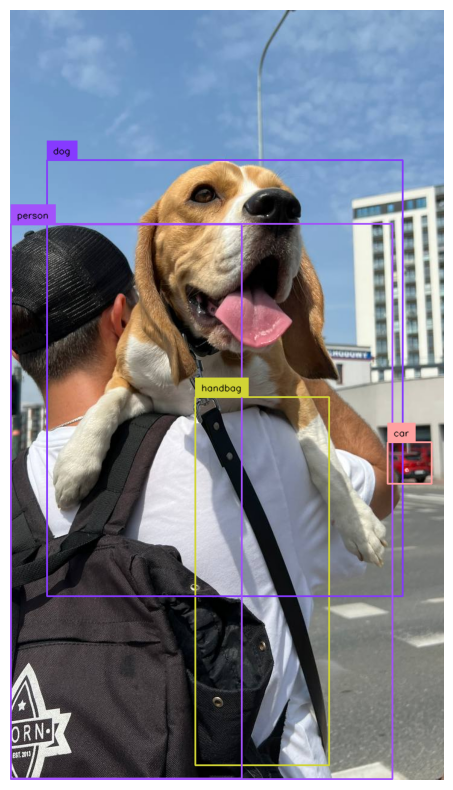

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("ngc-hong-hi-s-workspace")
project = workspace.project("soccernet-1ae2v-e6wqy")
version = project.version(3)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘{HOME}/datasets’: No such file or directory
[Errno 2] No such file or directory: '{HOME}/datasets'
/content


ModuleNotFoundError: No module named 'roboflow'

In [ ]:
!pip install wandb -q

import wandb
wandb.login()

from ultralytics import settings
settings.update({'wandb': True})


invalid escape sequence '\/'
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dohai30062005 (dohai30062005-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=32 imgsz=1280 plots=True batch=32

/content
100% 18.4M/18.4M [00:00<00:00, 154MB/s]
New https://pypi.org/project/ultralytics/8.4.35 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/soccernet-3/data.yaml, epochs=32, time=None, patience=100, batch=32, imgsz=1280, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    train_batch1.jpg
confusion_matrix_normalized.png			    train_batch27000.jpg
confusion_matrix.png				    train_batch27001.jpg
events.out.tfevents.1775562822.c6d937656991.5879.0  train_batch27002.jpg
F1_curve.png					    train_batch2.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
P_curve.png					    val_batch1_labels.jpg
PR_curve.png					    val_batch1_pred.jpg
R_curve.png					    val_batch2_labels.jpg
results.csv					    val_batch2_pred.jpg
results.png					    weights
train_batch0.jpg


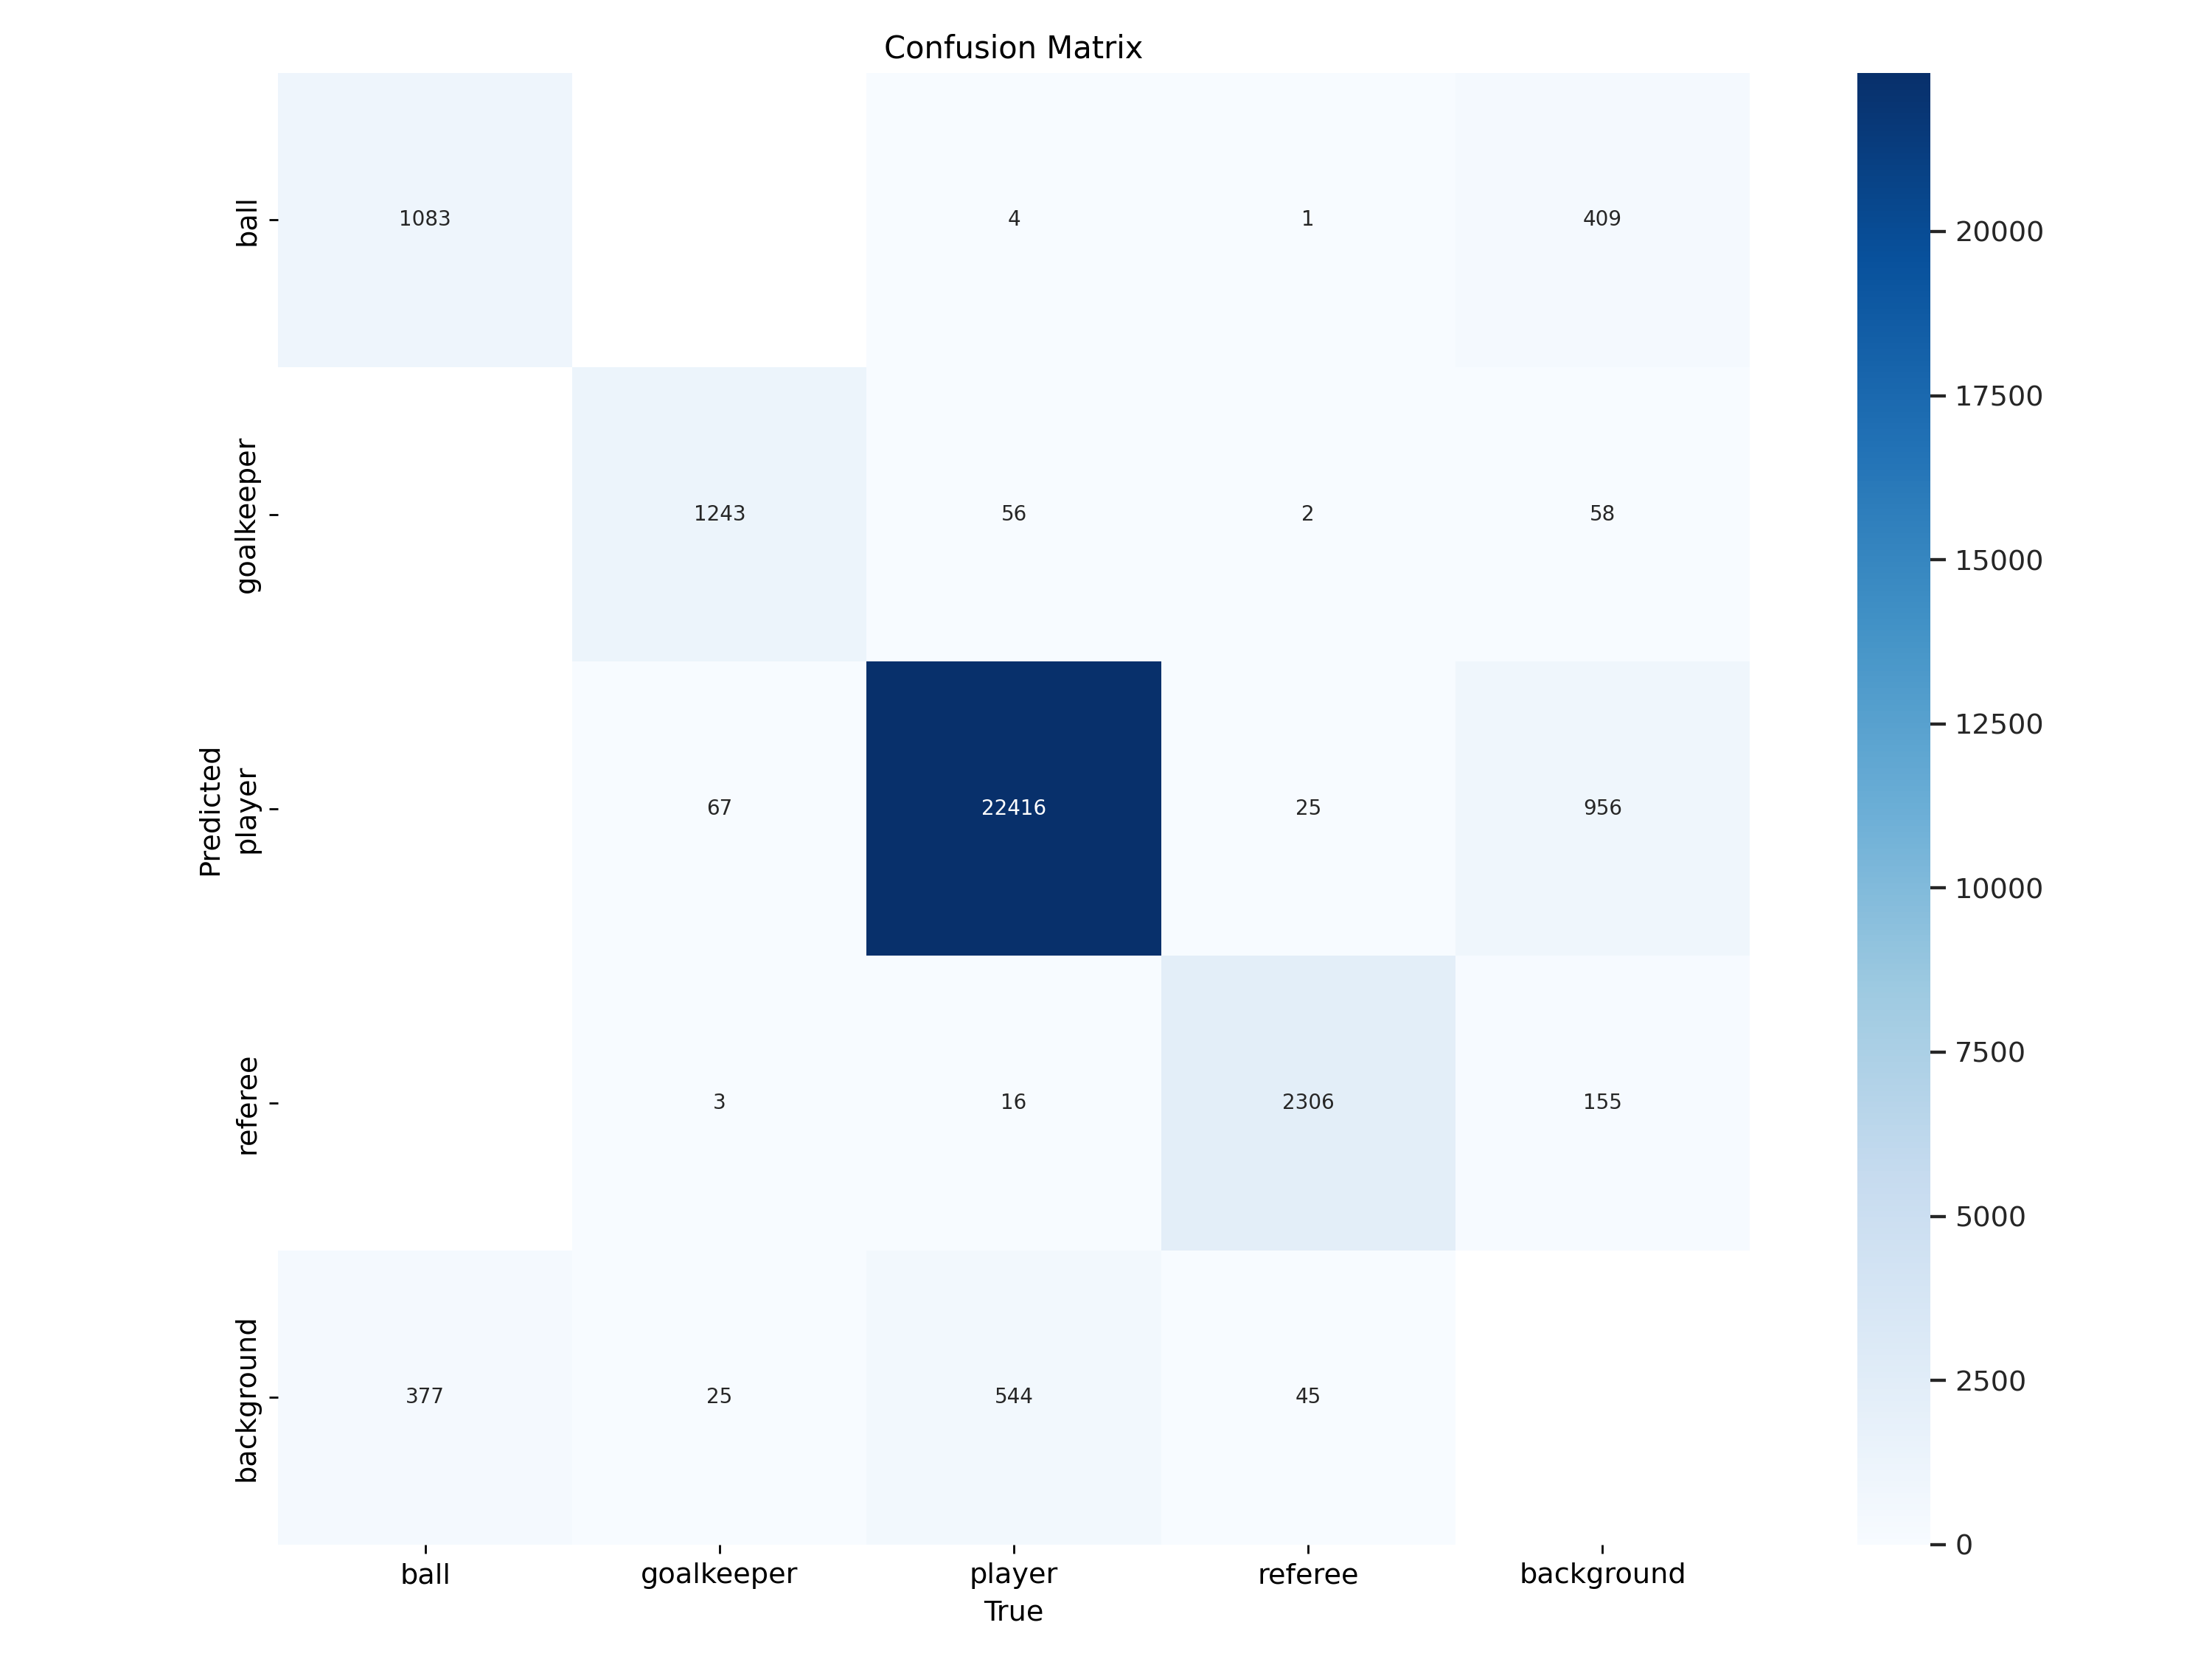

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

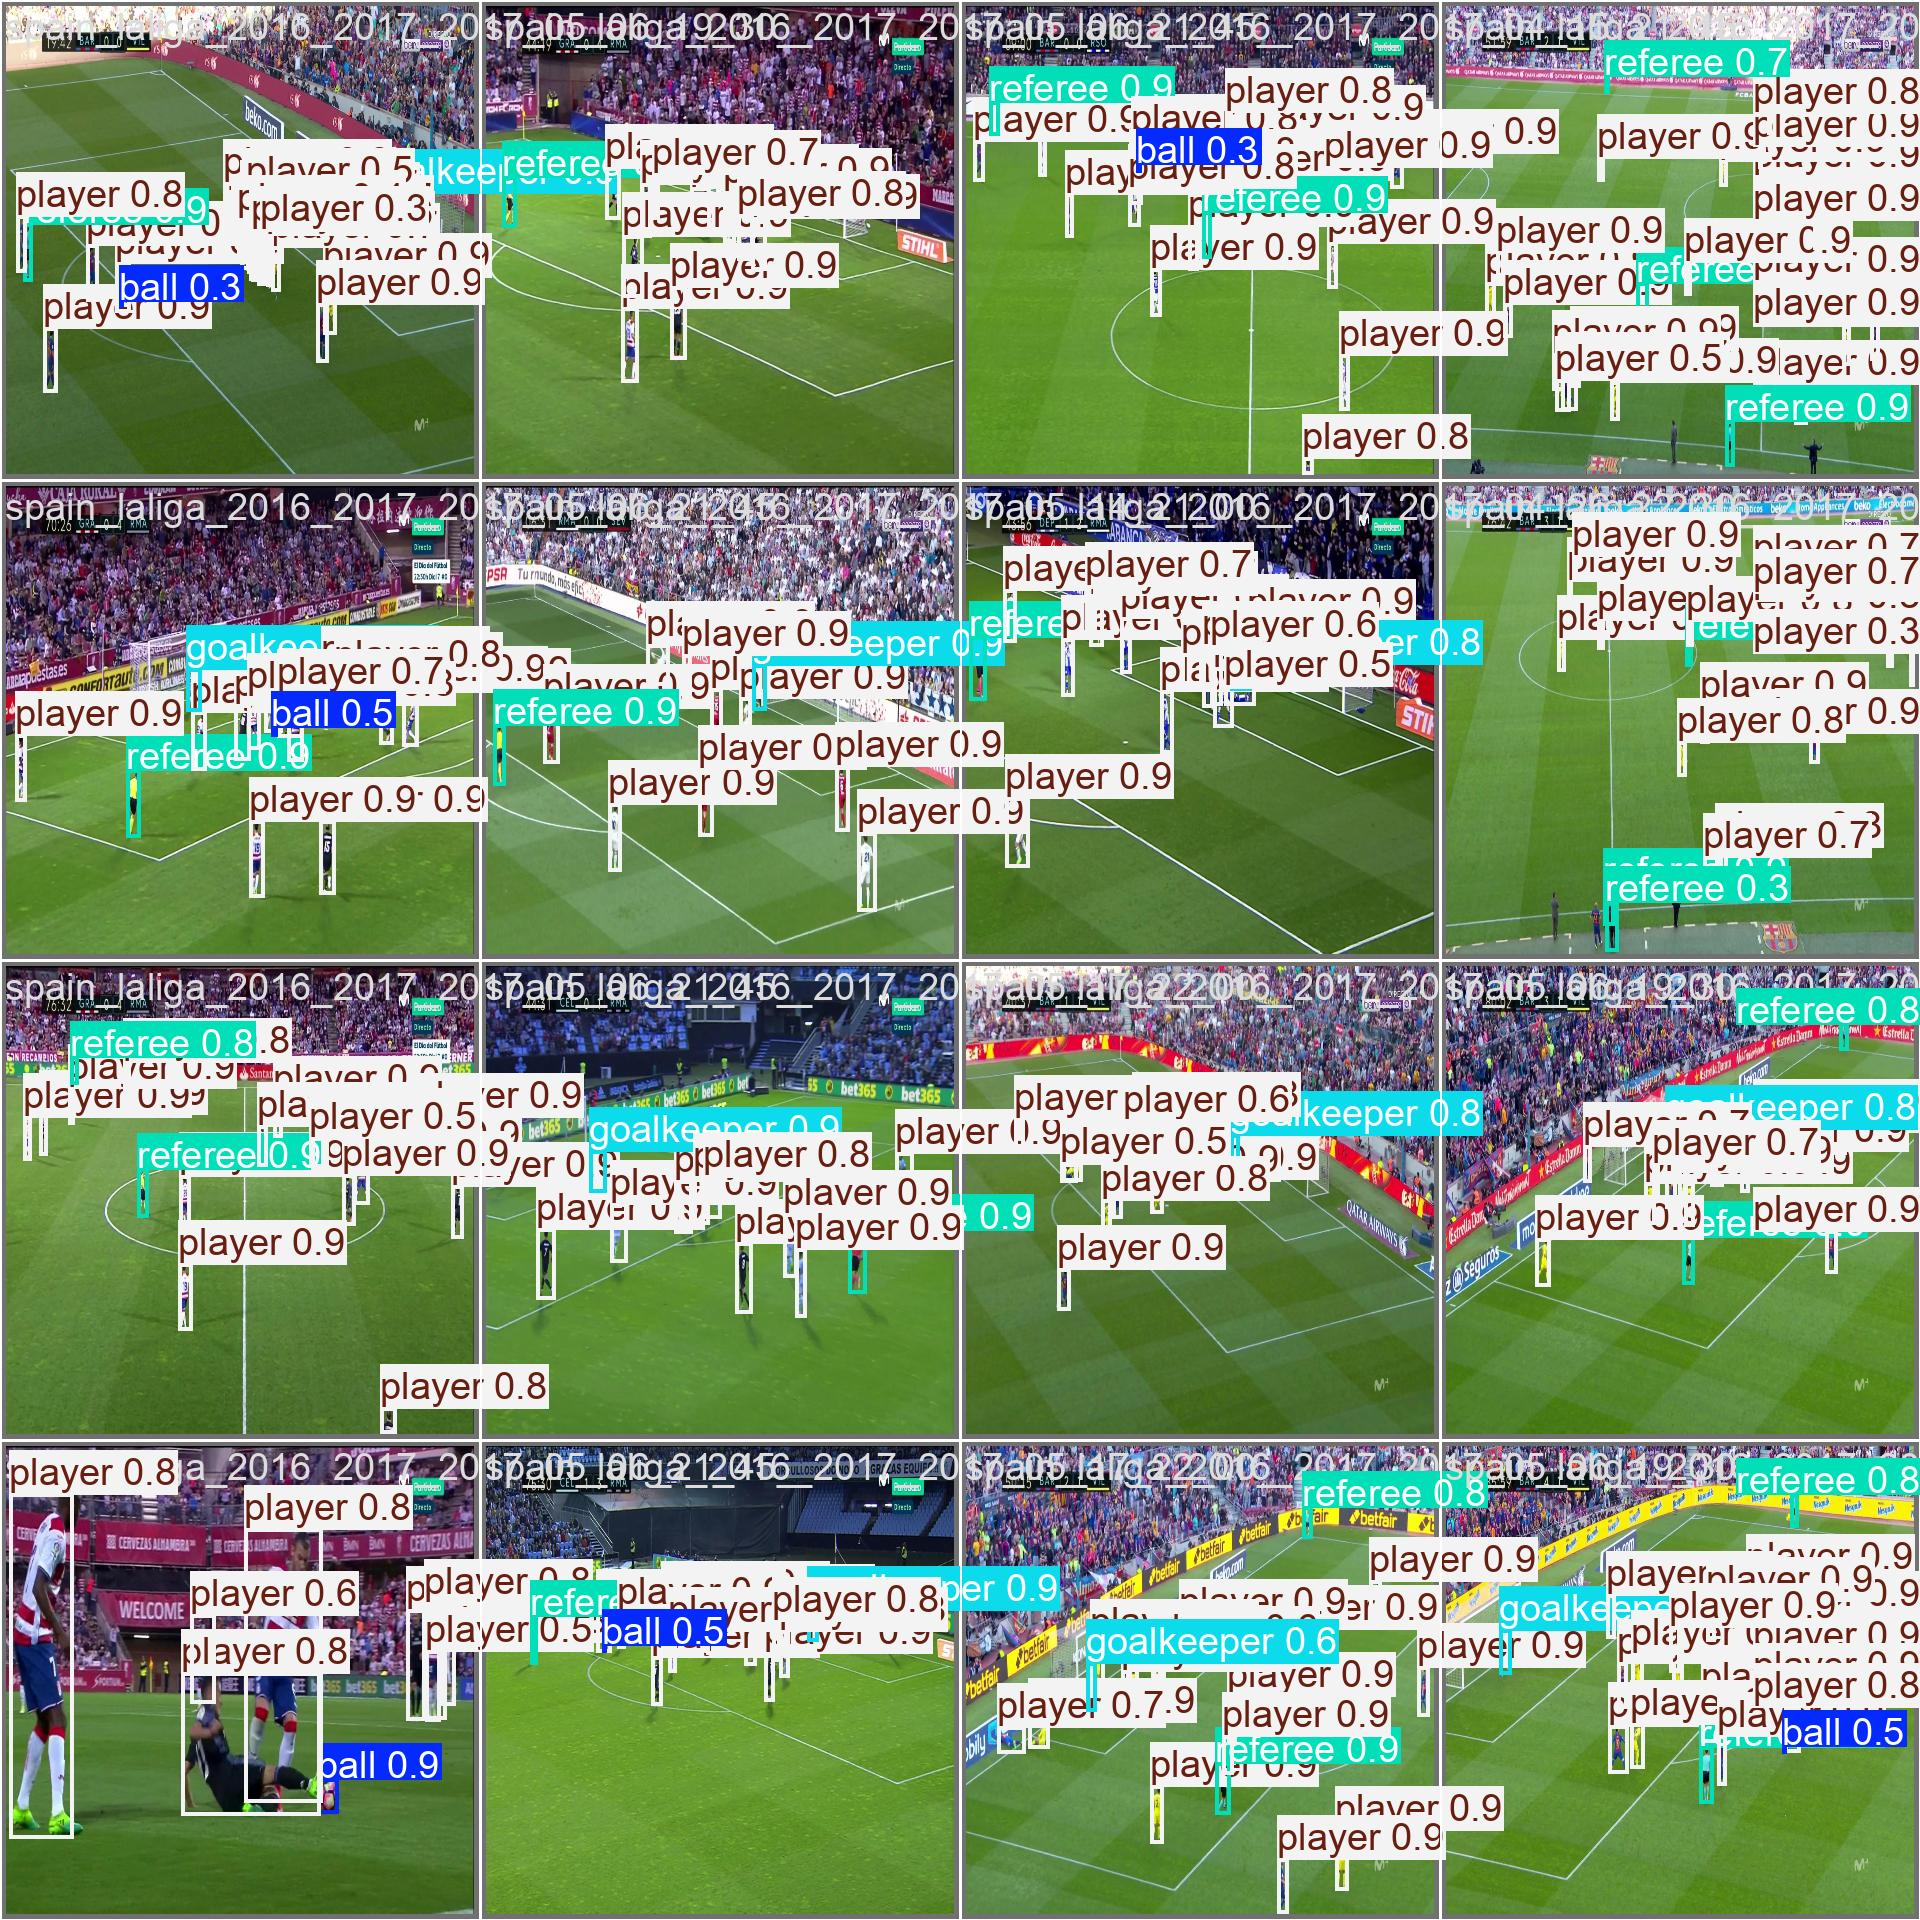

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/soccernet-2/valid/labels.cache... 1989 images, 77 backgrounds, 0 corrupt: 100% 1989/1989 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 125/125 [00:24<00:00,  5.00it/s]
                   all       1989      28213      0.902      0.882      0.897      0.655
                  ball       1460       1460      0.772      0.664      0.686      0.346
            goalkeeper       1317       1338      0.931      0.934      0.937      0.696
                player       1909      23036      0.965      0.964      0.985      0.792
               referee       1503       2379      0.941      0.968      0.982      0.788
Speed: 0.8ms preprocess, 4.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detec

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs

image 1/1313 /content/datasets/soccernet-2/test/images/08fd33_0_10_png_png.rf.36f3a9e28f2ed602d5c5b5c1c3ff4bb5.jpg: 1280x1280 (no detections), 9.5ms
image 2/1313 /content/datasets/soccernet-2/test/images/08fd33_0_5_png_png.rf.2c558d9f27a2bb8aae37216cafc6eeb0.jpg: 1280x1280 (no detections), 9.2ms
image 3/1313 /content/datasets/soccernet-2/test/images/08fd33_3_7_png_png.rf.36717c1a481516fc559b26f9ffe4a280.jpg: 1280x1280 (no detections), 8.9ms
image 4/1313 /content/datasets/soccernet-2/test/images/08fd33_6_6_png_png.rf.61e21ce5fef88bee349a55d9d751533e.jpg: 1280x1280 (no detections), 8.9ms
image 5/1313 /content/datasets/soccernet-2/test/images/08fd33_9_1_png_png.rf.9512096d8916aaf1c5fbcebb5dbb1c13.jpg: 1280x1280 (no detections), 9.2ms
image 6/1313 /content/datasets/soccernet-2/test/images/08fd33_9_7_png_png.rf.5

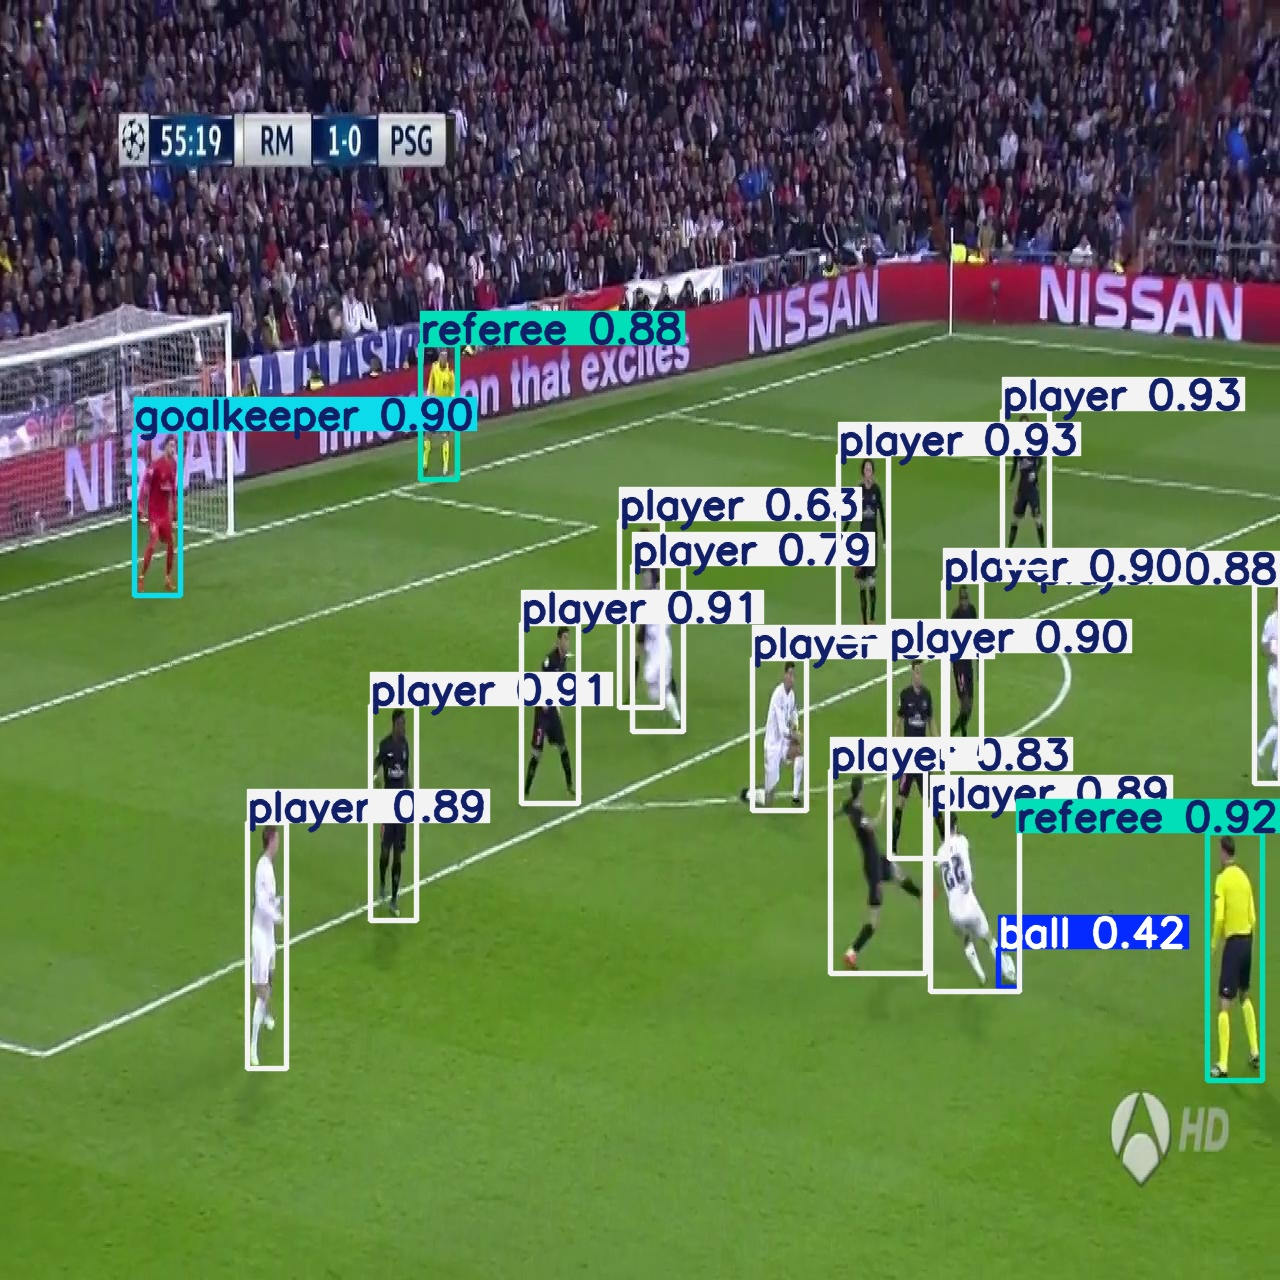

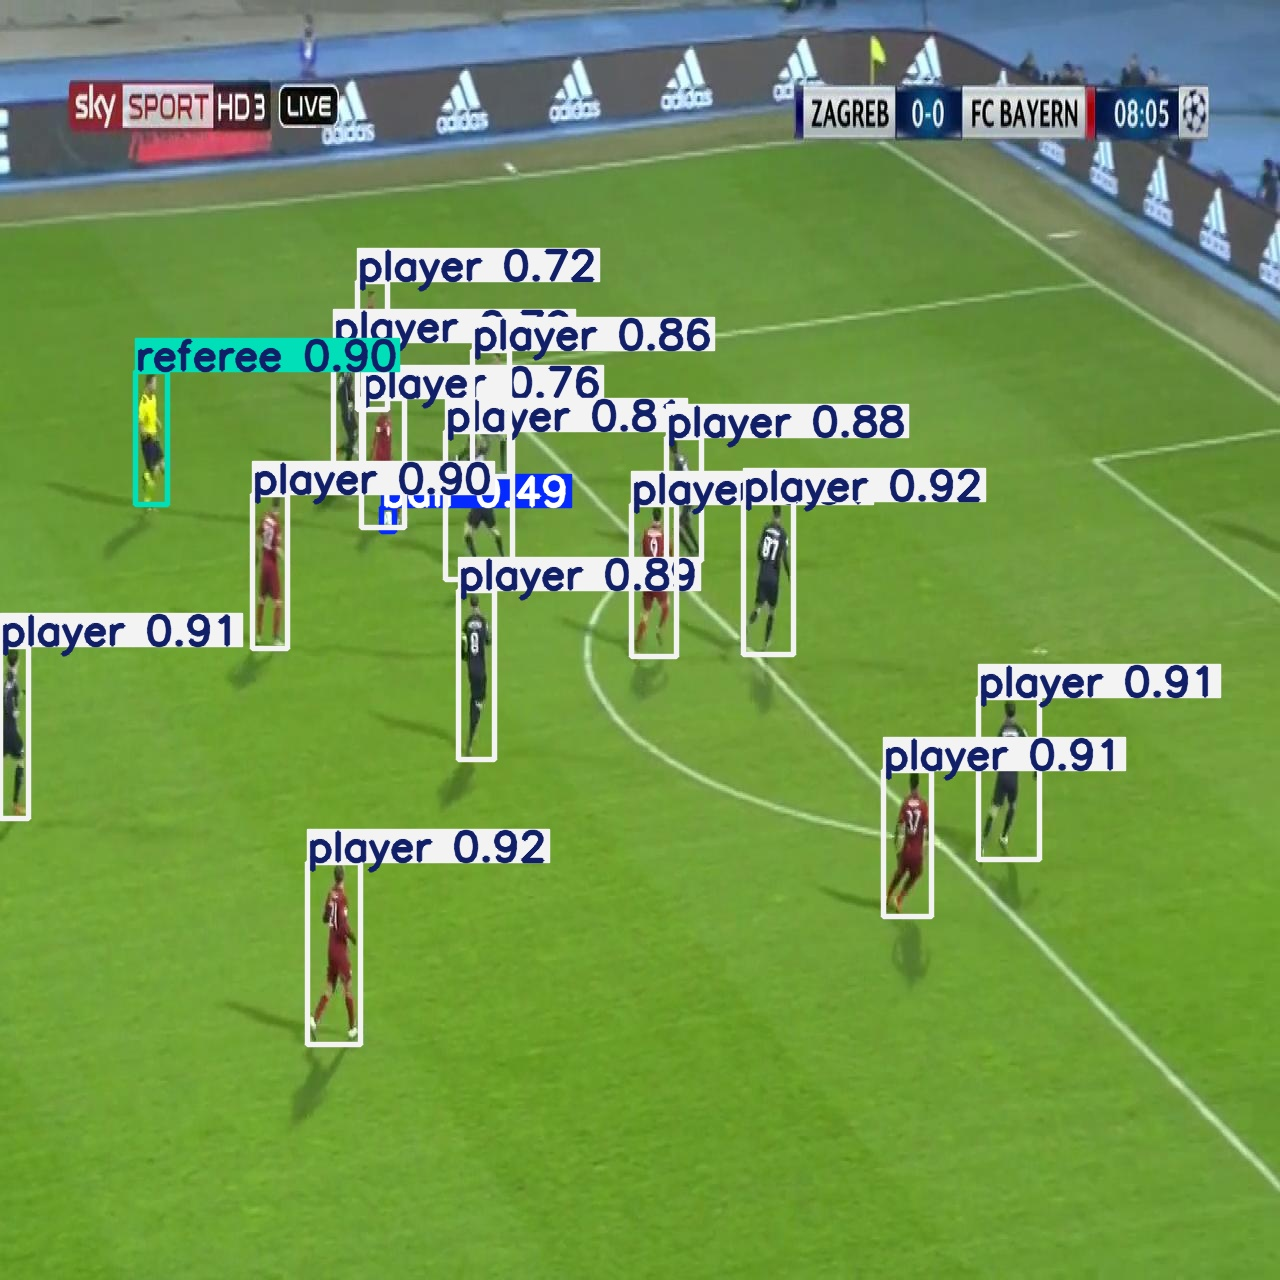

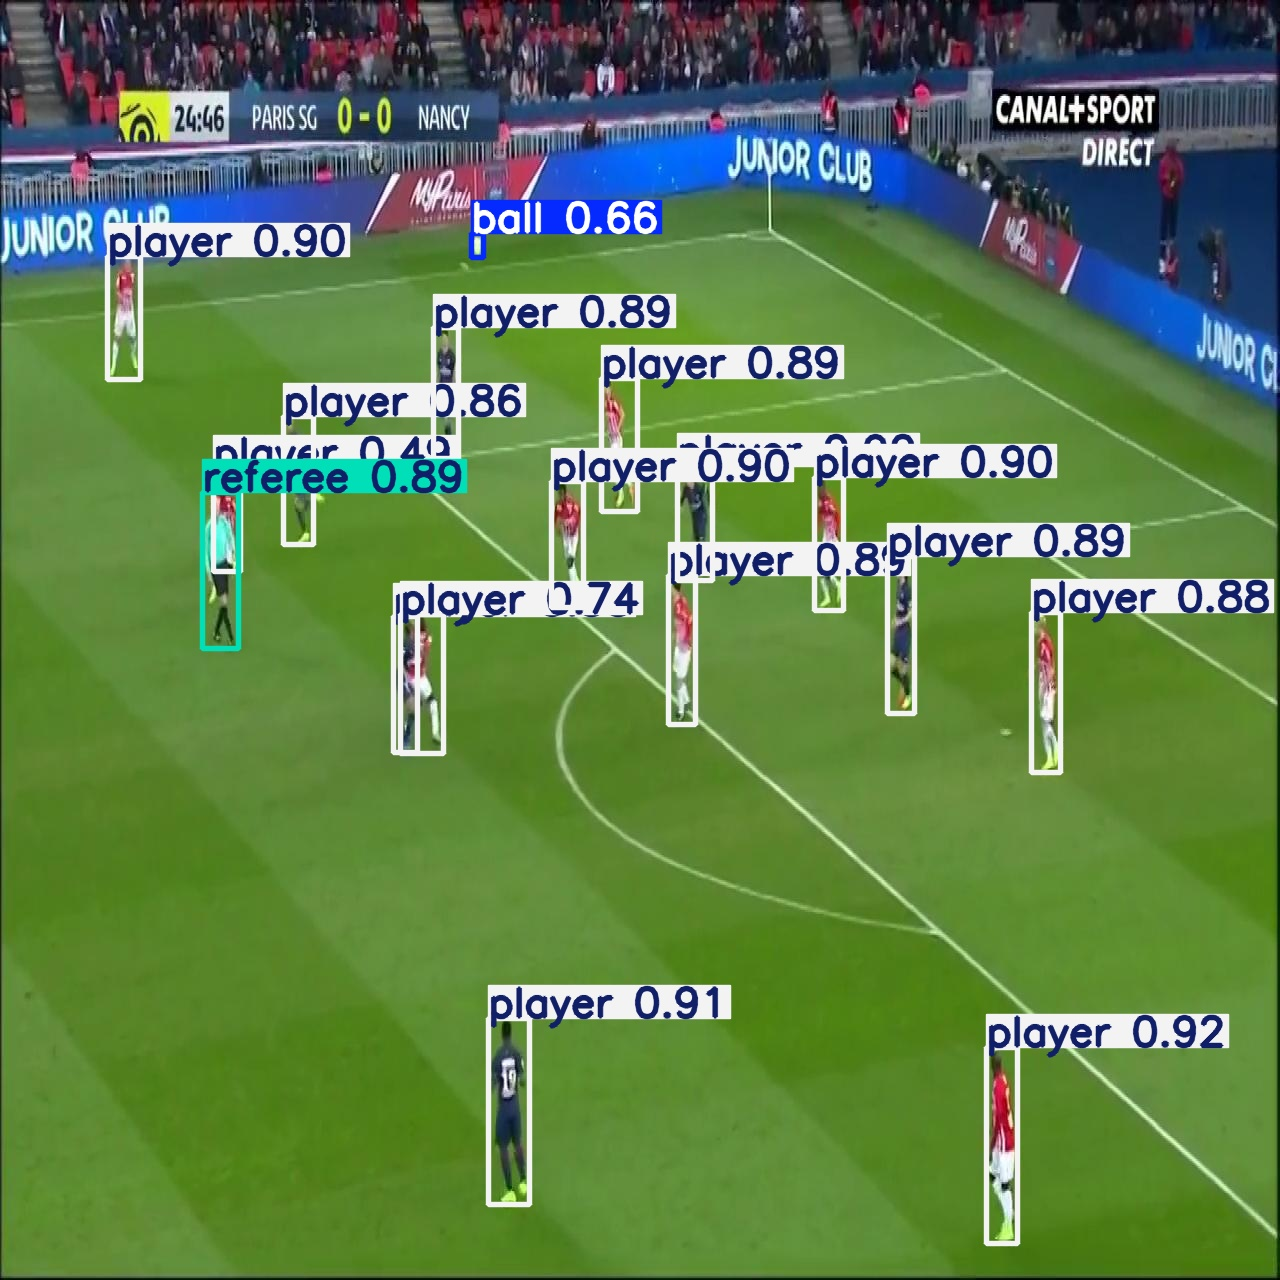

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

View the status of your deployment at: https://app.roboflow.com/ngc-hong-hi-s-workspace/soccernet-1ae2v-e6wqy/3
Share your model with the world at: https://universe.roboflow.com/ngc-hong-hi-s-workspace/soccernet-1ae2v-e6wqy/model/3


In [ ]:
!pip install inference supervision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 11.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB

In [ ]:
# Gỡ bỏ các phiên bản onnxruntime đang xung đột
!pip uninstall -y onnxruntime onnxruntime-gpu

# Cài đặt lại duy nhất phiên bản hỗ trợ GPU
!pip install onnxruntime-gpu

Found existing installation: onnxruntime 1.21.1
Uninstalling onnxruntime-1.21.1:
  Successfully uninstalled onnxruntime-1.21.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 10.4 MB/s eta 0:00:00


In [ ]:
!pip install pycuda
!pip install "inference[onnx-gpu]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 85.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.5 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=d6d4f08fb6fcecf439e7c36f13d72f04c7fc1311128caa1bd9ee652cfb03351a
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
Importing from timm.models.layers is deprecated, please import via timm.layers


Running inference on france_ligue_1_2015_2016_2015_11_07_19_00_Paris_SG_5_0_Toulouse_2_png.rf.11fa5ca48a14d5471f21e8674f305991.jpg


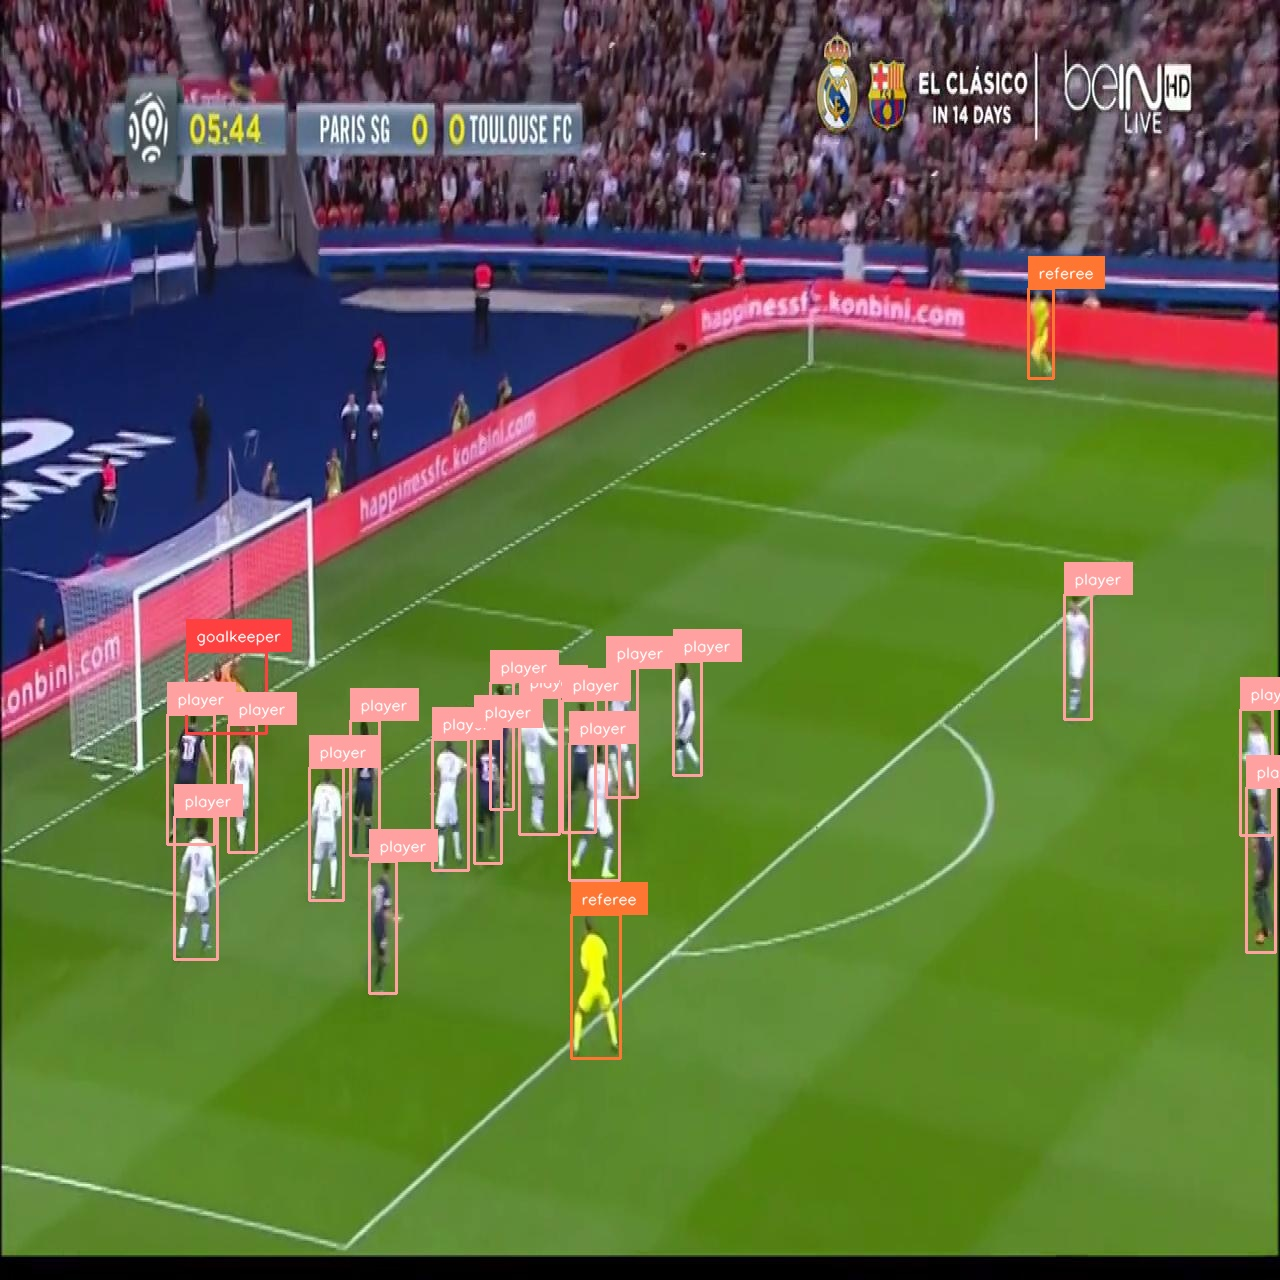

Running inference on europe_uefa_champions_league_2016_2017_2016_09_13_21_45_Barcelona_7_0_Celtic_6_png.rf.39365393cbef8c7adcdeb47536e2769e.jpg


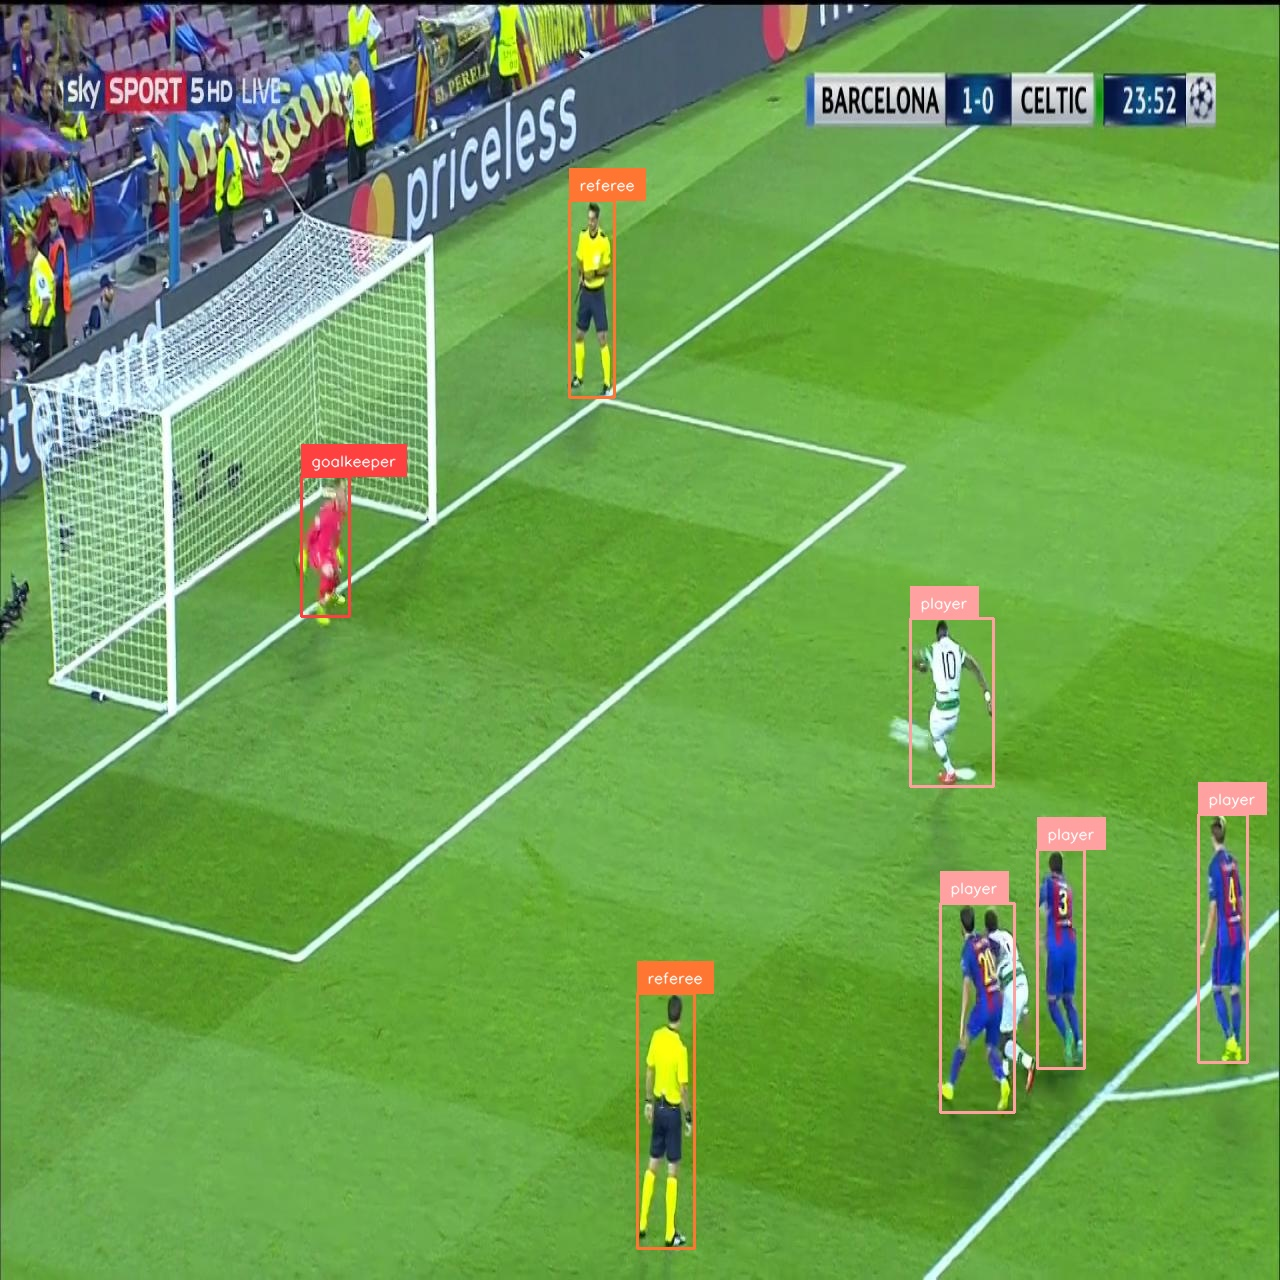

Running inference on europe_uefa_champions_league_2014_2015_2015_05_06_21_45_Barcelona_3_0_Bayern_Munich_12_png.rf.114e10bcf8d4262ef0b37646010b1d31.jpg


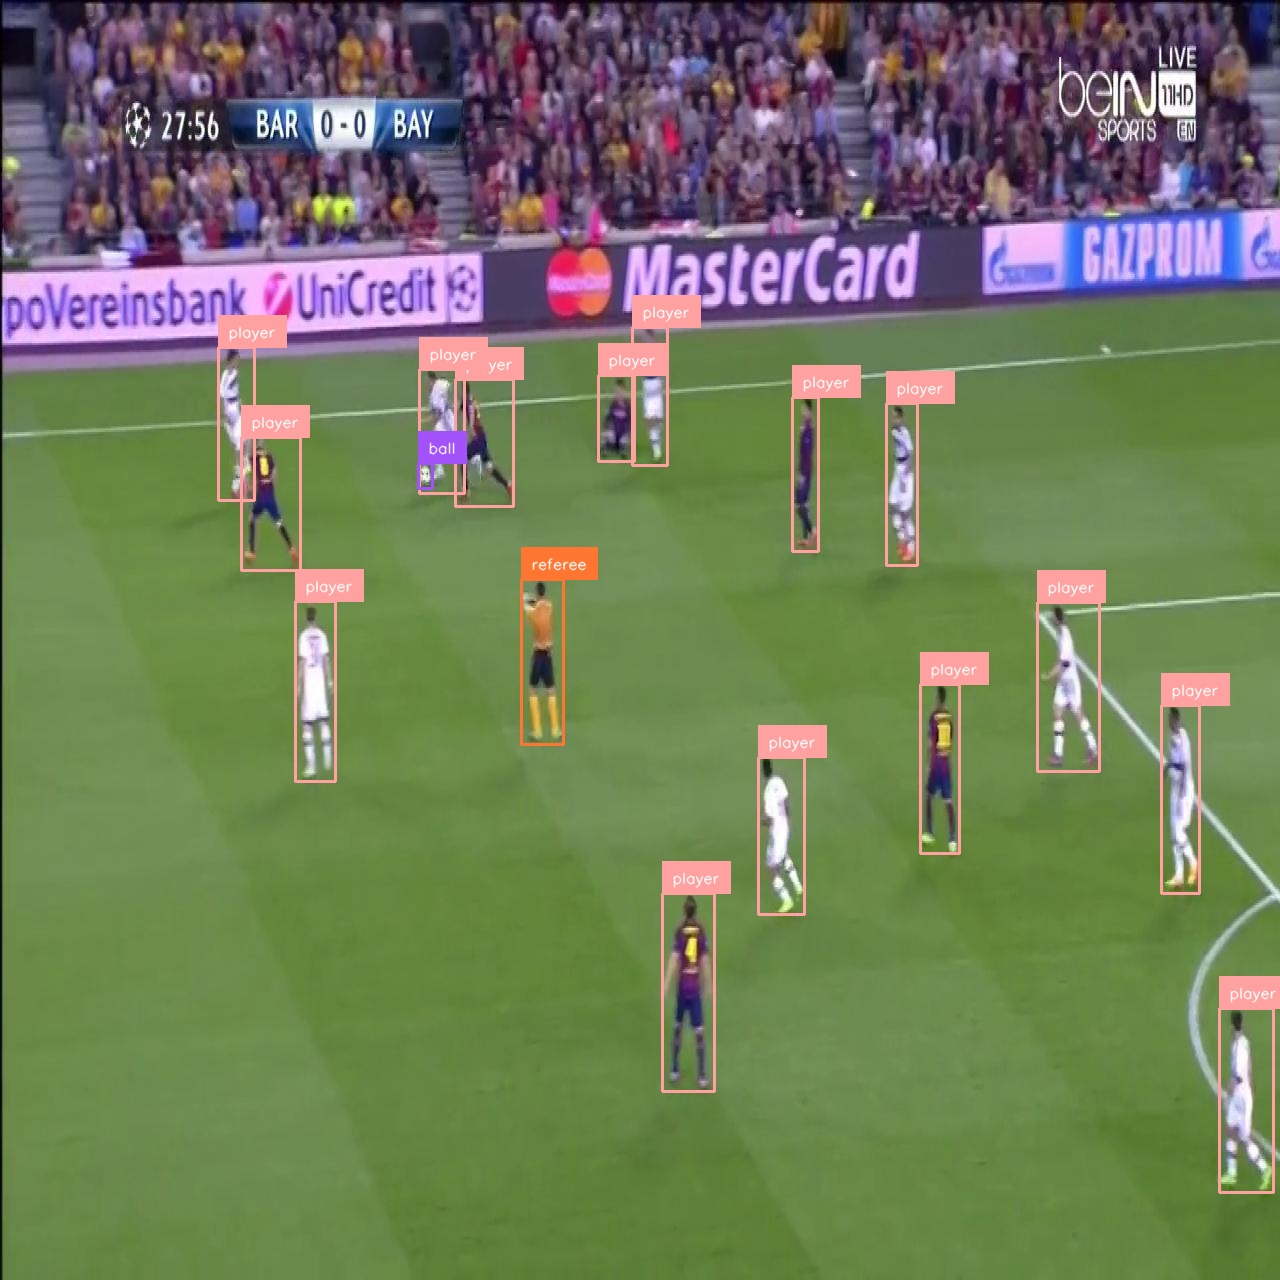

Running inference on germany_bundesliga_2014_2015_2015_05_16_16_30_Wolfsburg_2_1_Dortmund_1_png.rf.8c2aa68a5b87a178690473223828210e.jpg


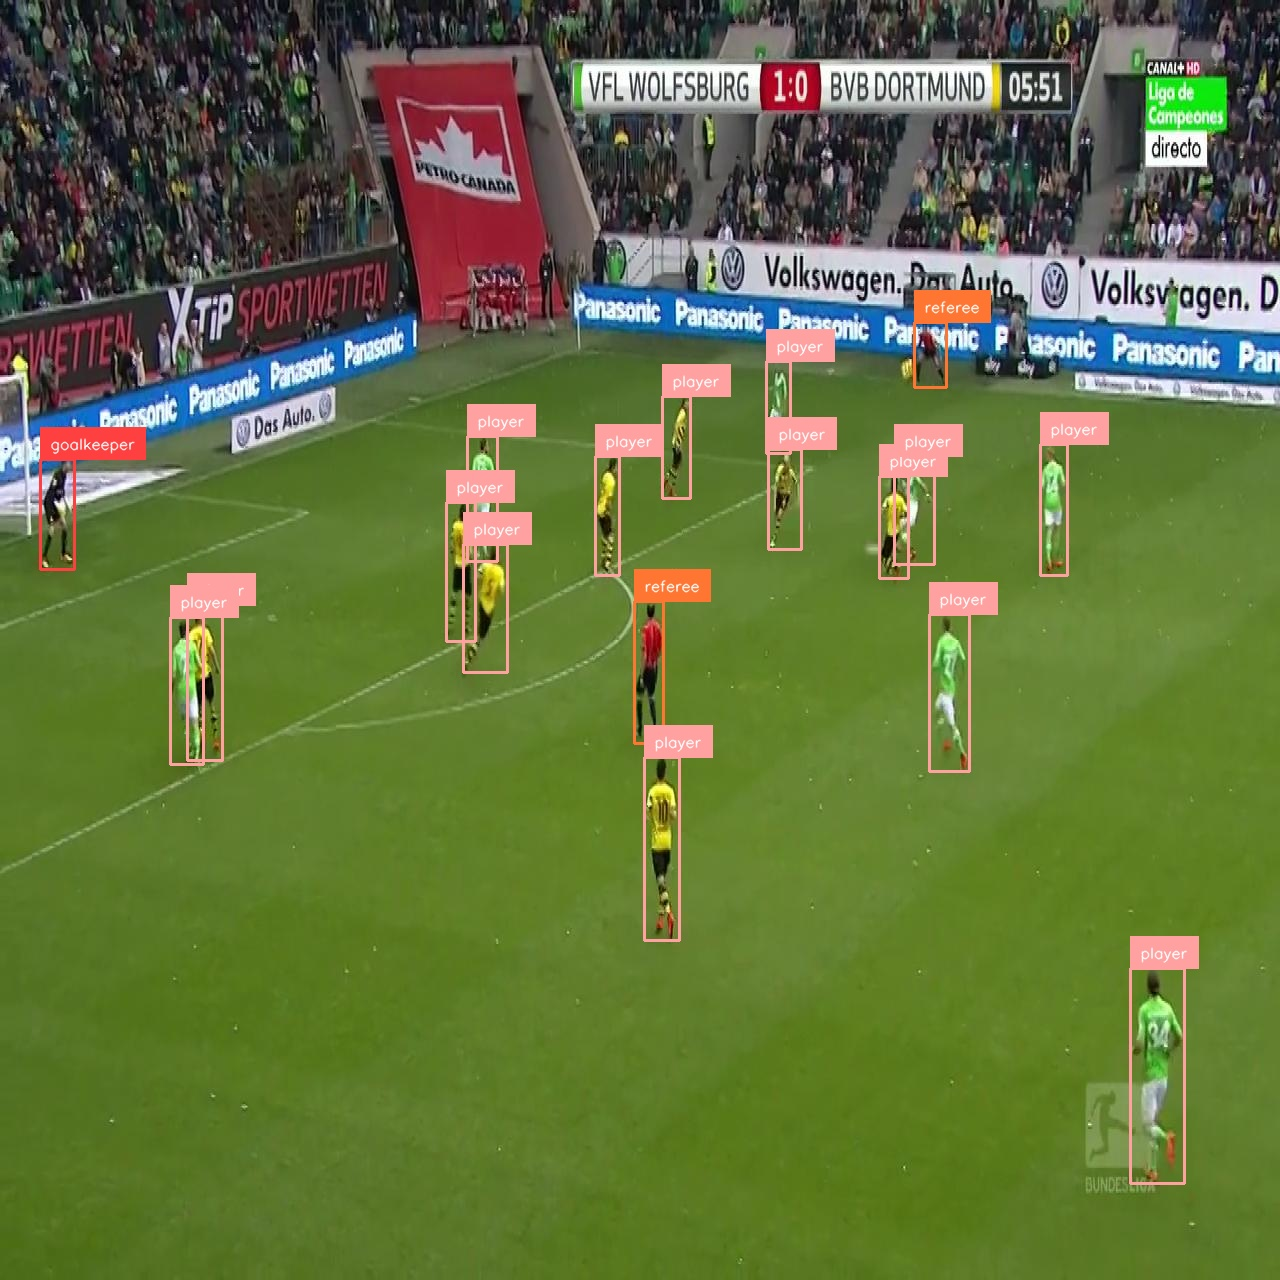

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


✅ Đang tiến hành phân tích bức ảnh: 2e57b9_1_7_png.rf.EQFfGYYqbFkh1iFIFW4j.png ...


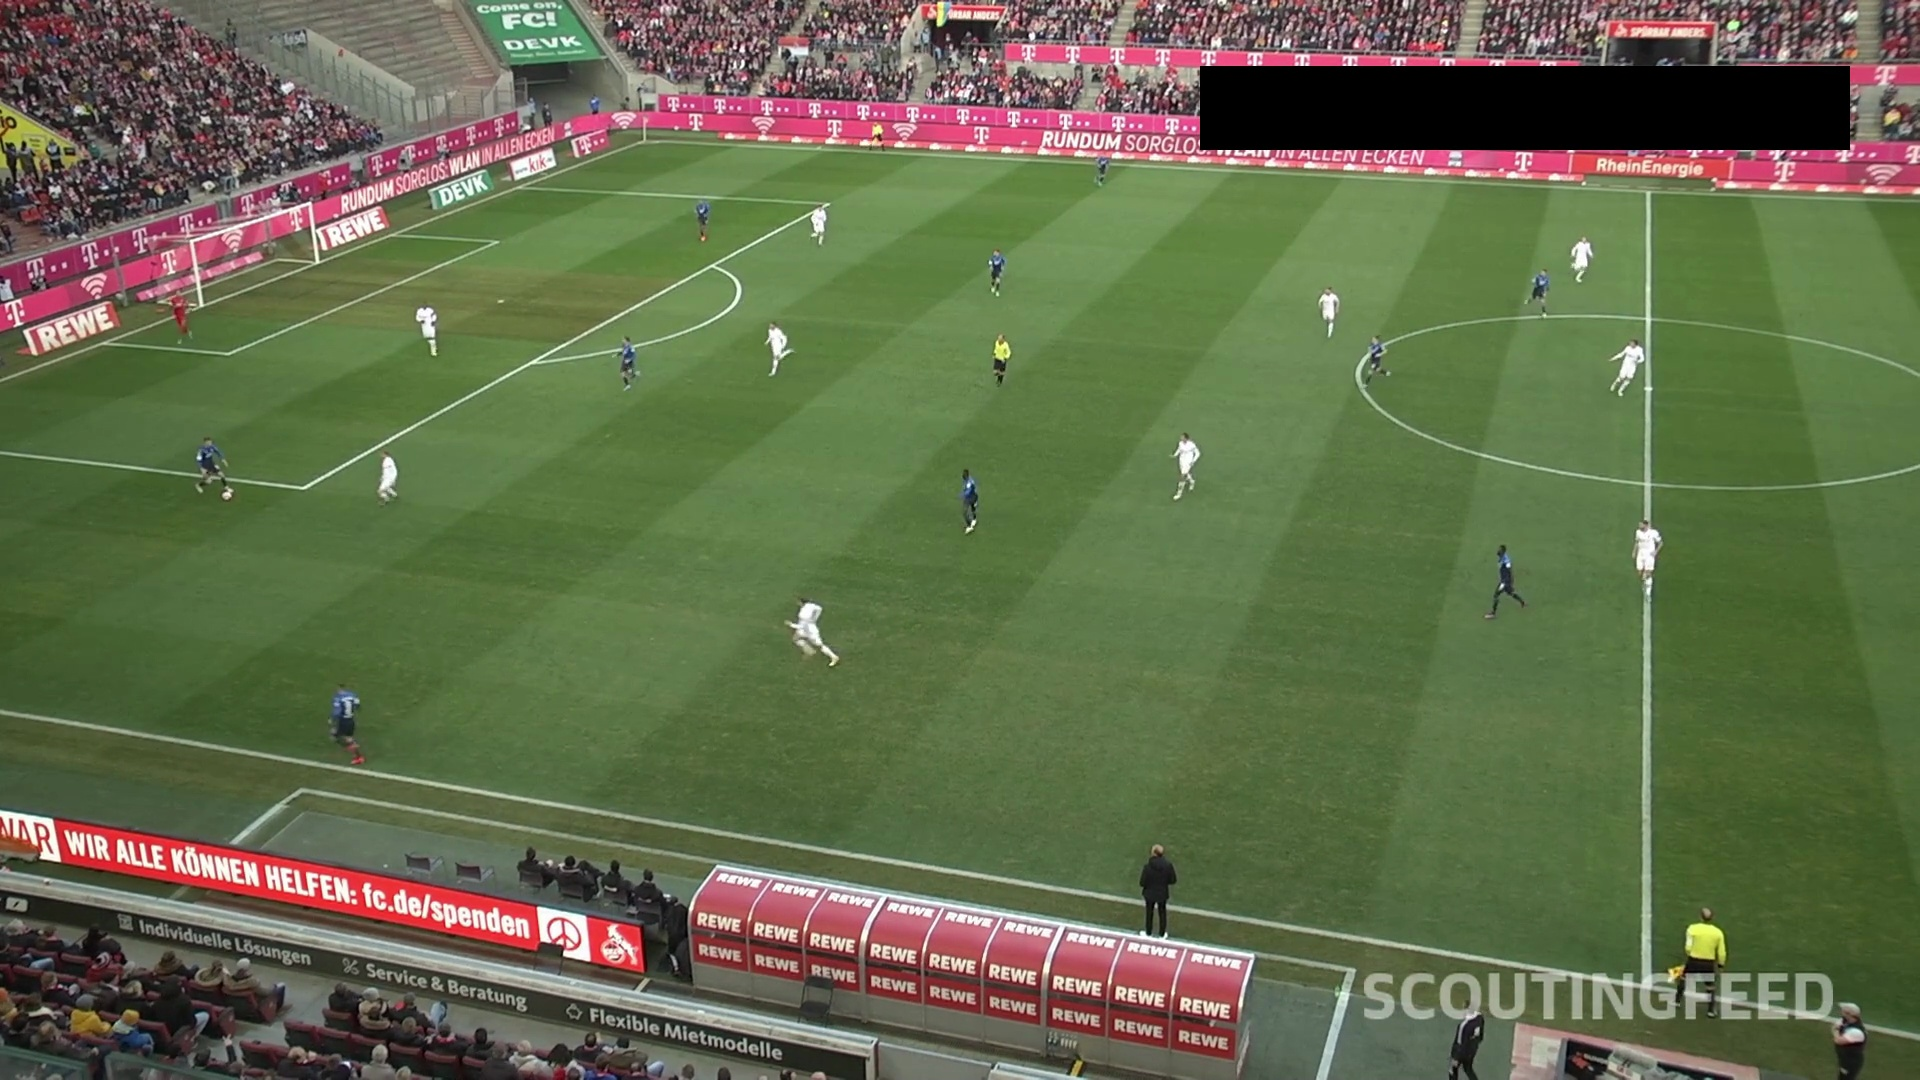

In [ ]:
import os
import cv2
import supervision as sv
import IPython
import inference
from google.colab import userdata

test_folder = "/content/test"
os.makedirs(test_folder, exist_ok=True)

valid_extensions = ('.png', '.jpg', '.jpeg')
test_images = [f for f in os.listdir(test_folder) if f.lower().endswith(valid_extensions)]

if len(test_images) == 0:
    print(f"Thư mục '{test_folder}' đang trống hoặc vừa mới được tạo.")
else:
    img_name = test_images[0]
    img_path = os.path.join(test_folder, img_name)

    model_id = project.id.split("/")[1] + "/" + dataset.version
    model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

    image = cv2.imread(img_path)

    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

✅ Đang tiến hành phân tích bức ảnh: 2e57b9_1_7_png.rf.EQFfGYYqbFkh1iFIFW4j.png ...


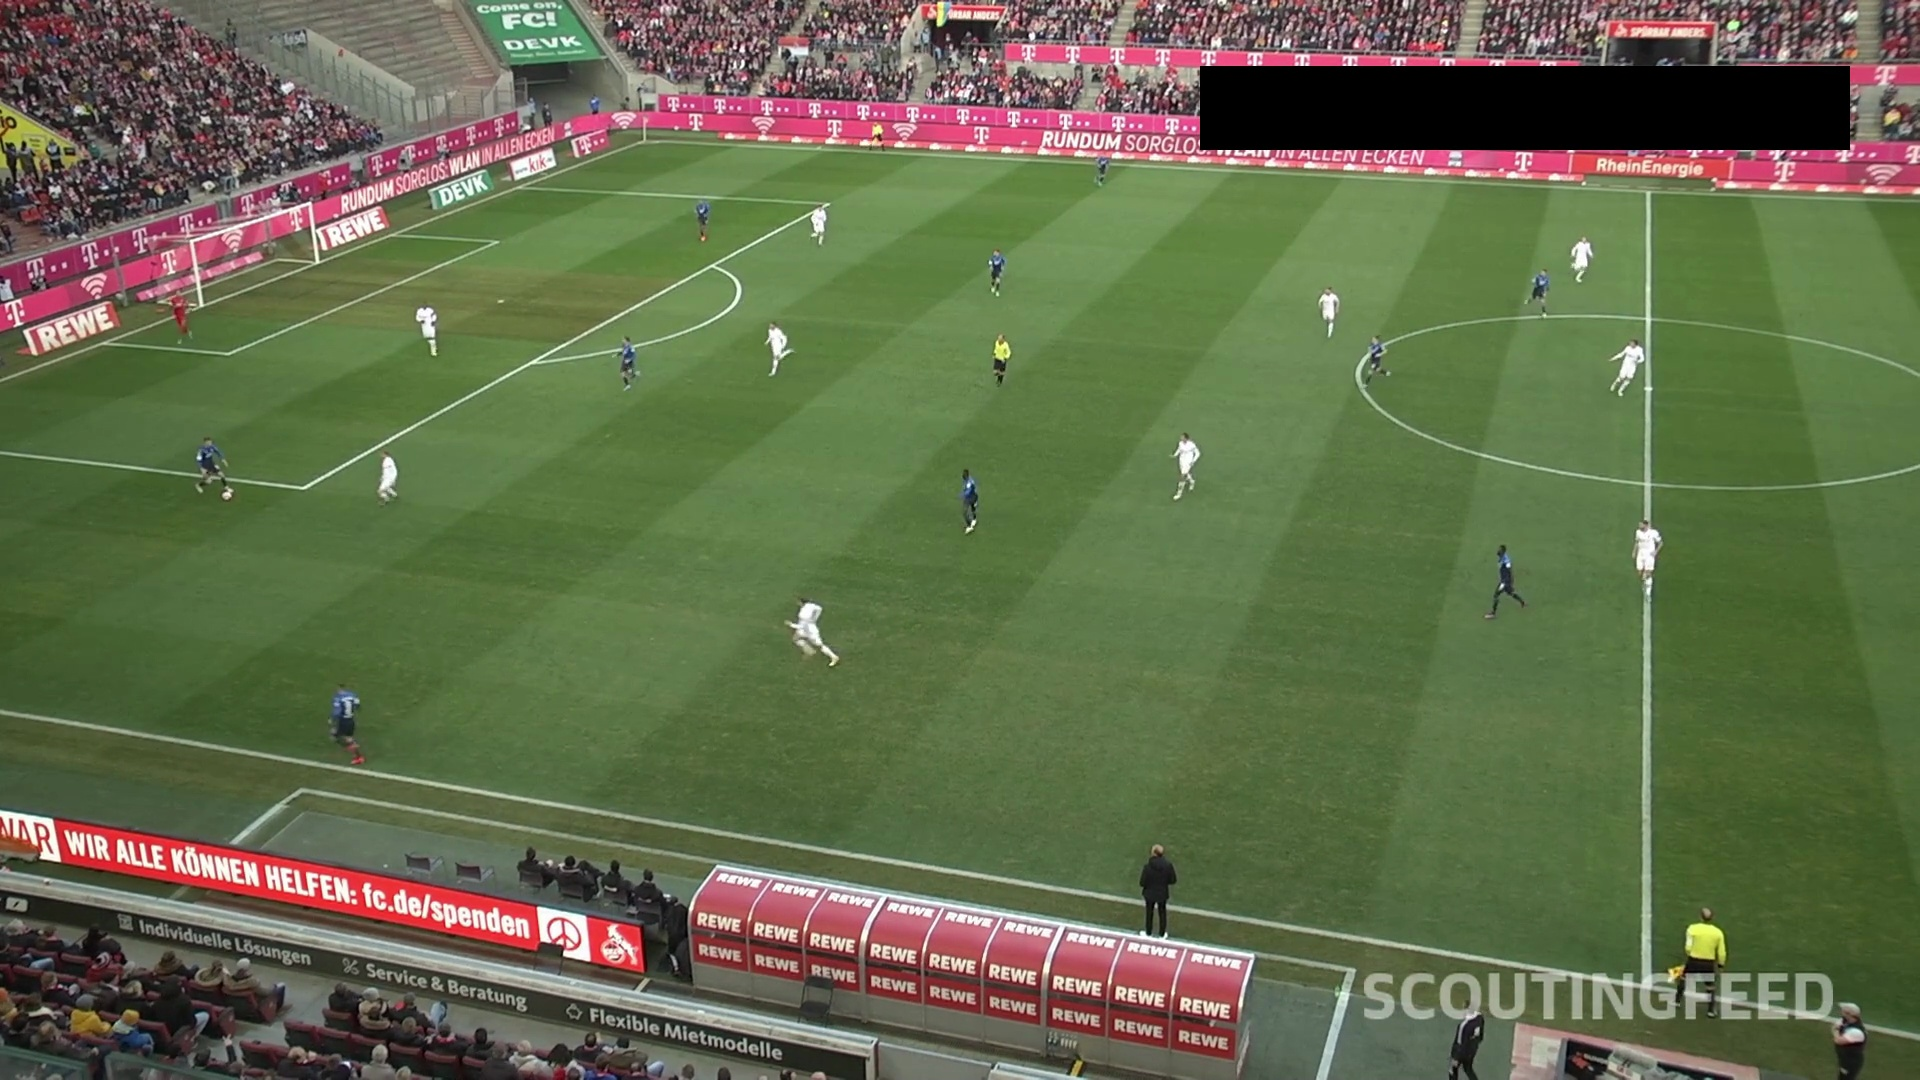

In [ ]:
import os
import cv2
import supervision as sv
import IPython
import inference
from google.colab import userdata

test_folder = "/content/test"
os.makedirs(test_folder, exist_ok=True)

valid_extensions = ('.png', '.jpg', '.jpeg')
test_images = [f for f in os.listdir(test_folder) if f.lower().endswith(valid_extensions)]

if len(test_images) == 0:
    print(f"Thư mục '{test_folder}' hiện đang trống hoặc vừa mới được tạo.")
else:
    img_name = test_images[0]
    img_path = os.path.join(test_folder, img_name)

    model_id = project.id.split("/")[1] + "/" + dataset.version
    model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

    image = cv2.imread(img_path)

    results = model.infer(image, imgsz=1280, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [ ]:
import shutil
import os
from google.colab import files

folder_path = '/content/runs/detect/train'

if not os.path.exists(folder_path):
    print(f"Lỗi: Không tìm thấy thư mục '{folder_path}'!")
else:
    shutil.make_archive('training_results', 'zip', folder_path)

    files.download('training_results.zip')

Đang nén thư mục '/content/runs/detect/train'...
✅ Nén thành công! Đang tiến hành tải về...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [ ]:
import getpass
from inference import get_model

MODEL_ID = "soccernet-1ae2v-e6wqy/2"
model_rf = get_model(model_id=MODEL_ID, api_key = userdata.get("ROBOFLOW_API_KEY"))

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/Do_An_AI/YOLO_Weights/training_results(3)/weights/best.pt')

results = model.predict(
    source='/content/drive/MyDrive/Do_An_AI/video_test.mp4',
    save=True
)



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/550) /content/drive/MyDrive/Do_An_AI/video_test.mp4: 736x1280 1 ball, 21 players, 4 referees, 11.6ms
video 1/1 (frame 2/550) /content/drive/MyDrive/Do_An_AI/video_test.mp4: 736x1280 1 ball, 21 players, 4 referees, 11.5ms
video 1/1 (frame 3/550) /content/drive/MyDrive/Do_An_AI/video_test.mp4: 736x1280 1 ball, 21 players, 4 referees, 9.9ms
video 1/1 (frame 4/550) /content/drive/MyDrive/Do_An_AI/video_test.mp4: 736x1280 3 balls, 20 play